# HPC Usage Statistics: User Perspective

This notebook visualises HPC cluster usage from a **user perspective**, focusing on **average efficiency metrics**. Average efficiency answers: "What's the typical job's efficiency?" — each job counts equally regardless of size.

**Use this notebook for:**
- User training and feedback sessions
- Identifying typical efficiency patterns and common issues
- Helping users understand how their jobs compare to others

For an infrastructure-focused view (weighted efficiency, where larger jobs contribute more), see `visualisation_infrastructure.ipynb`.

**Sections:**
1. [Overview](#1.-Overview) - Basic resource usage metrics by faculty
2. [Global Stats](#2.-Global-Stats) - Key metrics at a glance
3. [Detailed Analysis](#3.-Detailed-Analysis) - Comprehensive charts and comparisons
4. [Job-Level Distributions](#4.-Job-Level-Distributions) - Per-job efficiency patterns
5. [Correlation Analysis](#5.-Correlation-Analysis) - Relationships between metrics
6. [Why Efficiency Matters](#6.-Why-Efficiency-Matters) - Educational content
7. [Technical Appendix](#7.-Technical-Appendix) - Methodology

In [1]:
# Setup and imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display, Markdown

# Configuration: This notebook uses AVERAGE efficiency
EFFICIENCY_TYPE = 'average'
CPU_EFF_COL = 'avg_cpu_eff_pct'
MEM_EFF_COL = 'avg_mem_eff_pct'
TIME_EFF_COL = 'avg_time_eff_pct'
NOTEBOOK_TITLE = 'User Perspective'

# Set style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['figure.dpi'] = 100

In [2]:
# Load data
FACULTY_STATS_PATH = "../results/hpc_stats_output.csv"
JOB_LEVEL_PATH = "../results/job_level_metrics.csv"

df = pd.read_csv(FACULTY_STATS_PATH)
df['faculty'] = df['faculty'].str.strip('"')
df_faculties = df[df['faculty'] != 'all'].copy()
df_global = df[df['faculty'] == 'all'].copy()

# Convert NULL strings to NaN
df_faculties = df_faculties.replace('NULL', np.nan)
for col in df_faculties.columns:
    if col != 'faculty':
        df_faculties[col] = pd.to_numeric(df_faculties[col], errors='coerce')

# Faculty name mapping
FACULTY_MERGE = {
    "Faculty of Life Sciences and Medicine": "Faculty of Life Sciences & Medicine",
    "IoPPN": "Institute of Psychiatry, Psychology & Neuroscience",
    "Dentistry, Oral & Craniofacial Sciences": "Faculty of Dentistry, Oral & Craniofacial Sciences",
    "Social Science & Public Policy": "Faculty of Social Science & Public Policy",
}

df_faculties['faculty'] = df_faculties['faculty'].replace(FACULTY_MERGE)

# --- Re-aggregate after faculty merge ---
df_faculties['_cpu_eff_denom'] = np.where(
    df_faculties['weighted_cpu_eff_pct'] > 0,
    df_faculties['total_cpu_sec'] * 100 / df_faculties['weighted_cpu_eff_pct'], 0)
df_faculties['_time_eff_denom'] = np.where(
    df_faculties['weighted_time_eff_pct'] > 0,
    df_faculties['total_elapsed_sec'] * 100 / df_faculties['weighted_time_eff_pct'], 0)

sum_cols = [
    'job_count', 'job_count_success', 'job_count_failed',
    'count_completed', 'count_cancelled', 'count_failed',
    'count_timeout', 'count_node_fail', 'count_preempted',
    'total_elapsed_sec', 'total_cpu_sec', 'total_user_cpu_sec', 'total_sys_cpu_sec',
    'total_maxrss_bytes', 'total_reqmem_bytes',
    'total_alloccpus', 'total_nodes', 'total_wait_sec',
    '_cpu_eff_denom', '_time_eff_denom',
]

avg_eff_cols = ['avg_cpu_eff_pct', 'avg_mem_eff_pct', 'avg_time_eff_pct']
for col in avg_eff_cols:
    df_faculties[f'_{col}_wsum'] = df_faculties[col].fillna(0) * df_faculties['job_count']
    sum_cols.append(f'_{col}_wsum')

success_cols = [
    'success_weighted_cpu_eff_pct', 'success_avg_cpu_eff_pct',
    'success_weighted_mem_eff_pct', 'success_avg_mem_eff_pct',
    'success_weighted_time_eff_pct', 'success_avg_time_eff_pct',
]
for col in success_cols:
    df_faculties[f'_{col}_wsum'] = df_faculties[col].fillna(0) * df_faculties['job_count_success']
    sum_cols.append(f'_{col}_wsum')

df_faculties = df_faculties.groupby('faculty')[sum_cols].sum().reset_index()

# Recompute derived metrics
df_faculties['avg_elapsed_sec'] = df_faculties['total_elapsed_sec'] / df_faculties['job_count']
df_faculties['avg_cpu_sec'] = df_faculties['total_cpu_sec'] / df_faculties['job_count']
df_faculties['avg_maxrss_bytes'] = df_faculties['total_maxrss_bytes'] / df_faculties['job_count']
df_faculties['avg_reqmem_bytes'] = df_faculties['total_reqmem_bytes'] / df_faculties['job_count']
df_faculties['avg_alloccpus'] = df_faculties['total_alloccpus'] / df_faculties['job_count']
df_faculties['avg_wait_sec'] = df_faculties['total_wait_sec'] / df_faculties['job_count']

df_faculties['weighted_cpu_eff_pct'] = np.where(
    df_faculties['_cpu_eff_denom'] > 0,
    df_faculties['total_cpu_sec'] / df_faculties['_cpu_eff_denom'] * 100, np.nan)
df_faculties['weighted_mem_eff_pct'] = np.where(
    df_faculties['total_reqmem_bytes'] > 0,
    df_faculties['total_maxrss_bytes'] / df_faculties['total_reqmem_bytes'] * 100, np.nan)
df_faculties['weighted_time_eff_pct'] = np.where(
    df_faculties['_time_eff_denom'] > 0,
    df_faculties['total_elapsed_sec'] / df_faculties['_time_eff_denom'] * 100, np.nan)

for col in avg_eff_cols:
    df_faculties[col] = df_faculties[f'_{col}_wsum'] / df_faculties['job_count']

for col in success_cols:
    df_faculties[col] = np.where(
        df_faculties['job_count_success'] > 0,
        df_faculties[f'_{col}_wsum'] / df_faculties['job_count_success'], np.nan)

df_faculties = df_faculties.drop(columns=[c for c in df_faculties.columns if c.startswith('_')])
df_plot = df_faculties.sort_values('job_count', ascending=True)

print(f"Loaded aggregate data: {len(df_faculties)} faculties")
print(f"Total jobs: {df_faculties['job_count'].sum():,}")

Loaded aggregate data: 10 faculties
Total jobs: 220,741


In [3]:
# Shortened faculty names for plot labels
import textwrap

def _shorten_faculty(name):
    s = name.replace("Faculty of ", "").replace("Institute of ", "")
    return '\n'.join(textwrap.wrap(s, width=25))

df_faculties['faculty_short'] = df_faculties['faculty'].apply(_shorten_faculty)
FACULTY_SHORT = dict(zip(df_faculties['faculty'], df_faculties['faculty_short']))
df_plot = df_faculties.sort_values('job_count', ascending=True)

# Try to load per-job data
try:
    df_jobs = pd.read_csv(JOB_LEVEL_PATH)
    if 'faculty' in df_jobs.columns:
        df_jobs['faculty'] = df_jobs['faculty'].str.strip('"')
        df_jobs['faculty'] = df_jobs['faculty'].replace(FACULTY_MERGE)
        df_jobs['faculty_short'] = df_jobs['faculty'].map(FACULTY_SHORT).fillna(df_jobs['faculty'])
    df_jobs = df_jobs.replace('NULL', np.nan)
    for col in ['cpu_eff_pct', 'mem_eff_pct', 'time_eff_pct', 'wait_sec', 'elapsed_sec']:
        if col in df_jobs.columns:
            df_jobs[col] = pd.to_numeric(df_jobs[col], errors='coerce')
    HAS_JOB_DATA = True
    print(f"Loaded per-job data: {len(df_jobs):,} jobs")
except FileNotFoundError:
    HAS_JOB_DATA = False
    print(f"Note: {JOB_LEVEL_PATH} not found. Distribution analysis will be skipped.")

Loaded per-job data: 220,741 jobs


---
# 1. Overview

Basic resource usage metrics by faculty.

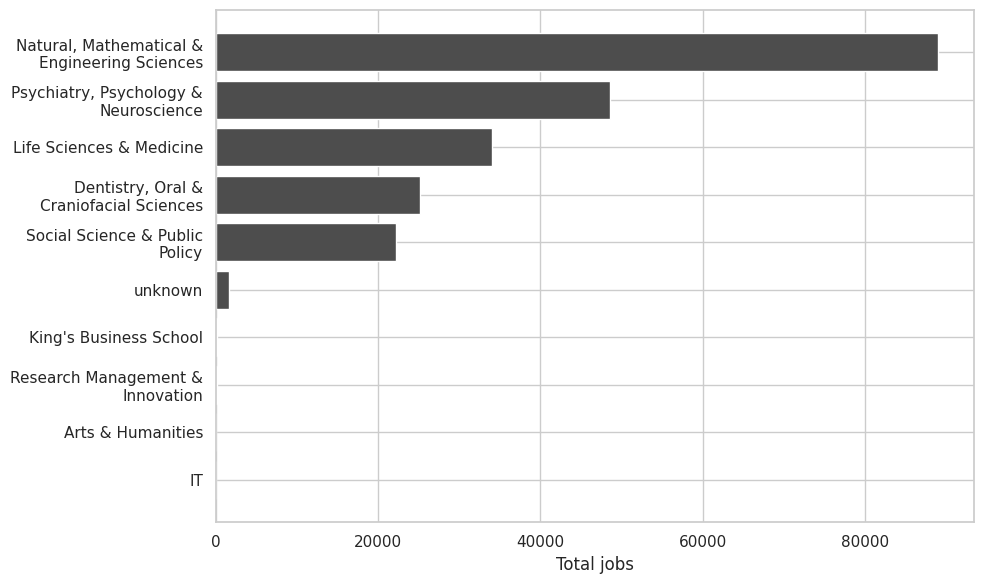

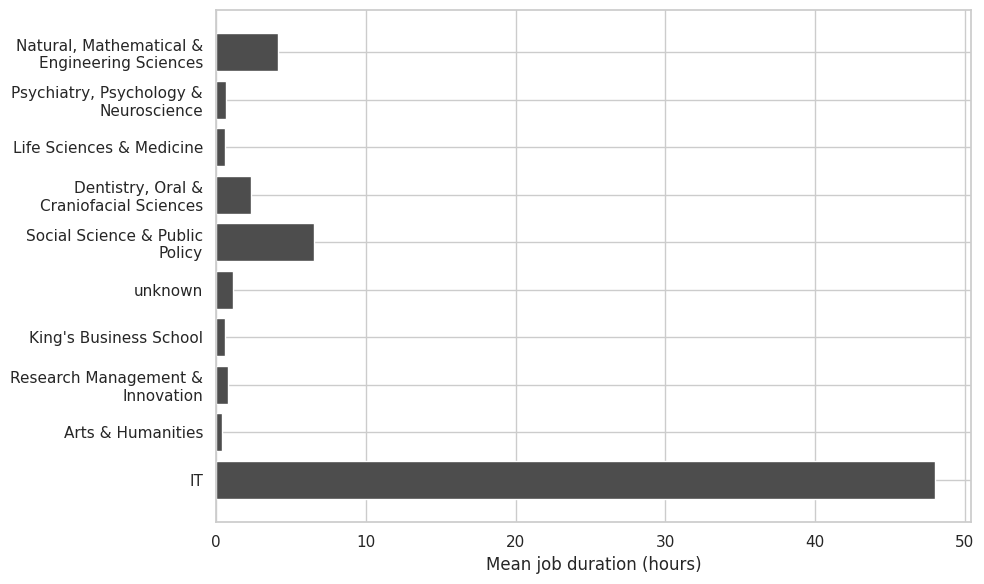

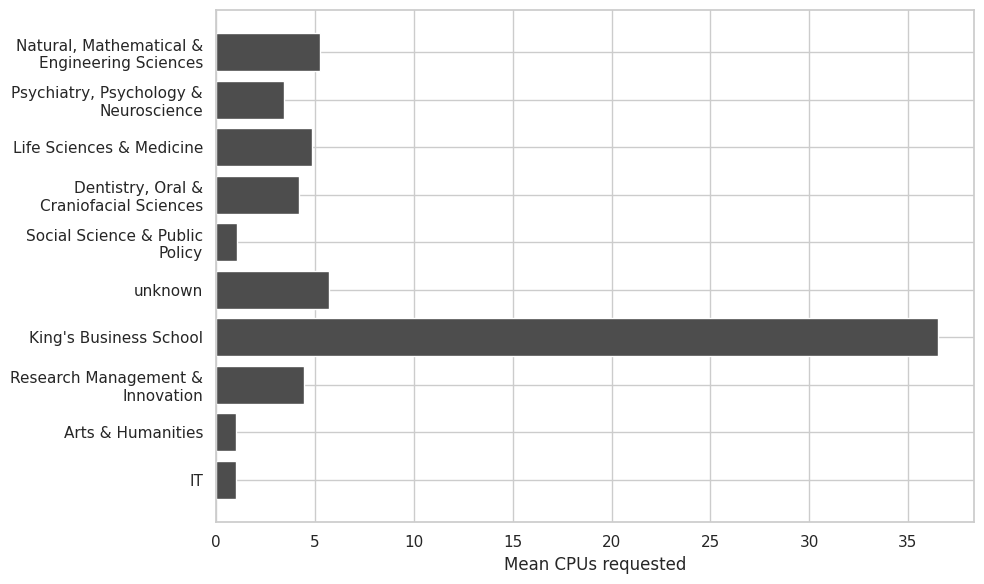

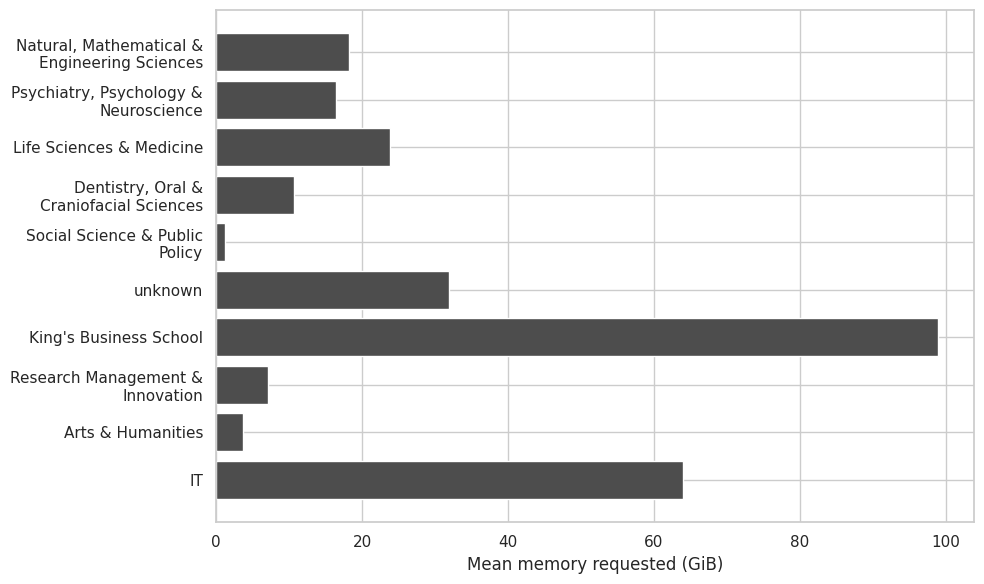

In [4]:
BAR_COLOR = '#4d4d4d'

def overview_bar(values, labels, xlabel):
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(labels, values, color=BAR_COLOR)
    ax.set_xlabel(xlabel)
    plt.tight_layout()
    plt.show()

overview_bar(df_plot['job_count'], df_plot['faculty_short'], 'Total jobs')
overview_bar(df_plot['avg_elapsed_sec'] / 3600, df_plot['faculty_short'], 'Mean job duration (hours)')
overview_bar(df_plot['avg_alloccpus'], df_plot['faculty_short'], 'Mean CPUs requested')
overview_bar(df_plot['avg_reqmem_bytes'] / (1024**3), df_plot['faculty_short'], 'Mean memory requested (GiB)')

---
# 2. Global Stats

Key metrics using **average efficiency** (mean across all jobs, each job counts equally).

In [5]:
def create_summary():
    total_jobs = df_faculties['job_count'].sum()
    total_success = df_faculties['job_count_success'].sum()
    success_rate = (total_success / total_jobs * 100) if total_jobs > 0 else 0
    
    # For average efficiency, compute job-weighted mean across faculties
    total_job_count = df_faculties['job_count'].sum()
    global_cpu_eff = (df_faculties[CPU_EFF_COL] * df_faculties['job_count']).sum() / total_job_count
    global_mem_eff = (df_faculties[MEM_EFF_COL] * df_faculties['job_count']).sum() / total_job_count
    
    if HAS_JOB_DATA and 'wait_sec' in df_jobs.columns:
        median_wait = df_jobs['wait_sec'].median() / 60
    else:
        median_wait = df_faculties['avg_wait_sec'].median() / 60
    
    summary = f"""
## Cluster-Wide Summary (Average Efficiency)

| Metric | Value |
|--------|-------|
| **Total Jobs** | {total_jobs:,} |
| **Success Rate** | {success_rate:.1f}% |
| **CPU Efficiency** (average) | {global_cpu_eff:.1f}% |
| **Memory Efficiency** (average) | {global_mem_eff:.1f}% |
| **Median Queue Wait** | {median_wait:.1f} min |

*Average efficiency = mean of per-job efficiencies. Each job counts equally regardless of size.*
"""
    display(Markdown(summary))

create_summary()


## Cluster-Wide Summary (Average Efficiency)

| Metric | Value |
|--------|-------|
| **Total Jobs** | 220,741 |
| **Success Rate** | 83.9% |
| **CPU Efficiency** (average) | 64.6% |
| **Memory Efficiency** (average) | 97.8% |
| **Median Queue Wait** | 20.8 min |

*Average efficiency = mean of per-job efficiencies. Each job counts equally regardless of size.*


In [6]:
def efficiency_ranking():
    ranking = df_faculties[['faculty', 'job_count', CPU_EFF_COL, MEM_EFF_COL, 'job_count_failed']].copy()
    ranking['failure_rate'] = (ranking['job_count_failed'] / ranking['job_count'] * 100).round(1)
    ranking = ranking.sort_values(CPU_EFF_COL, ascending=False)
    
    display(Markdown("### Faculty Ranking by Average CPU Efficiency"))
    display(Markdown("*Average efficiency shows typical job performance — each job counts equally.*"))
    display(ranking[['faculty', 'job_count', CPU_EFF_COL, MEM_EFF_COL, 'failure_rate']].rename(columns={
        'faculty': 'Faculty', 'job_count': 'Jobs', CPU_EFF_COL: 'CPU Eff %',
        MEM_EFF_COL: 'Mem Eff %', 'failure_rate': 'Failure %'
    }))

efficiency_ranking()

### Faculty Ranking by Average CPU Efficiency

*Average efficiency shows typical job performance — each job counts equally.*

,Faculty,Jobs,CPU Eff %,Mem Eff %,Failure %
4,Faculty of Social Science & Public Policy,22147,87.961467,31.998955,6.3
1,"Faculty of Dentistry, Oral & Craniofacial Scie...",25190,72.499512,325.812124,13.7
0,Faculty of Arts & Humanities,28,70.230000,5756.120000,42.9
3,"Faculty of Natural, Mathematical & Engineering...",89044,69.490000,51.700000,15.5
2,Faculty of Life Sciences & Medicine,34005,53.595363,68.333051,22.8
6,"Institute of Psychiatry, Psychology & Neurosci...",48634,49.844720,112.654413,18.2
9,unknown,1575,34.690000,65.540000,14.4
7,King's Business School,72,5.990000,27.210000,11.1
8,Research Management & Innovation,44,4.490000,7.850000,70.5
5,IT,2,0.010000,0.750000,100.0


**Column definitions:**
- **Jobs**: Total number of jobs submitted by the faculty
- **CPU Eff %**: Average CPU efficiency (mean of per-job efficiencies)
- **Mem Eff %**: Average memory efficiency (mean of per-job efficiencies)
- **Failure %**: Percentage of jobs that did not complete successfully (includes TIMEOUT and OUT_OF_MEMORY states)

**Observations:**

- **Faculty of Social Science & Public Policy**: Excellent CPU efficiency (88%) while submitting a substantial number of jobs (~22k). A model for efficient cluster usage.

- **Faculty of Natural, Mathematical & Engineering Sciences**: Good average efficiency (68%) — typical jobs are reasonably efficient. They submit the most jobs by far (~89k).

- **Faculty of Arts & Humanities**: Moderate CPU efficiency (36%), but very high memory efficiency values and a high failure rate (43%). The sample size is very small (28 jobs), so not statistically representative.

---
# 3. Detailed Analysis

## 3.1 Average Efficiency by Faculty

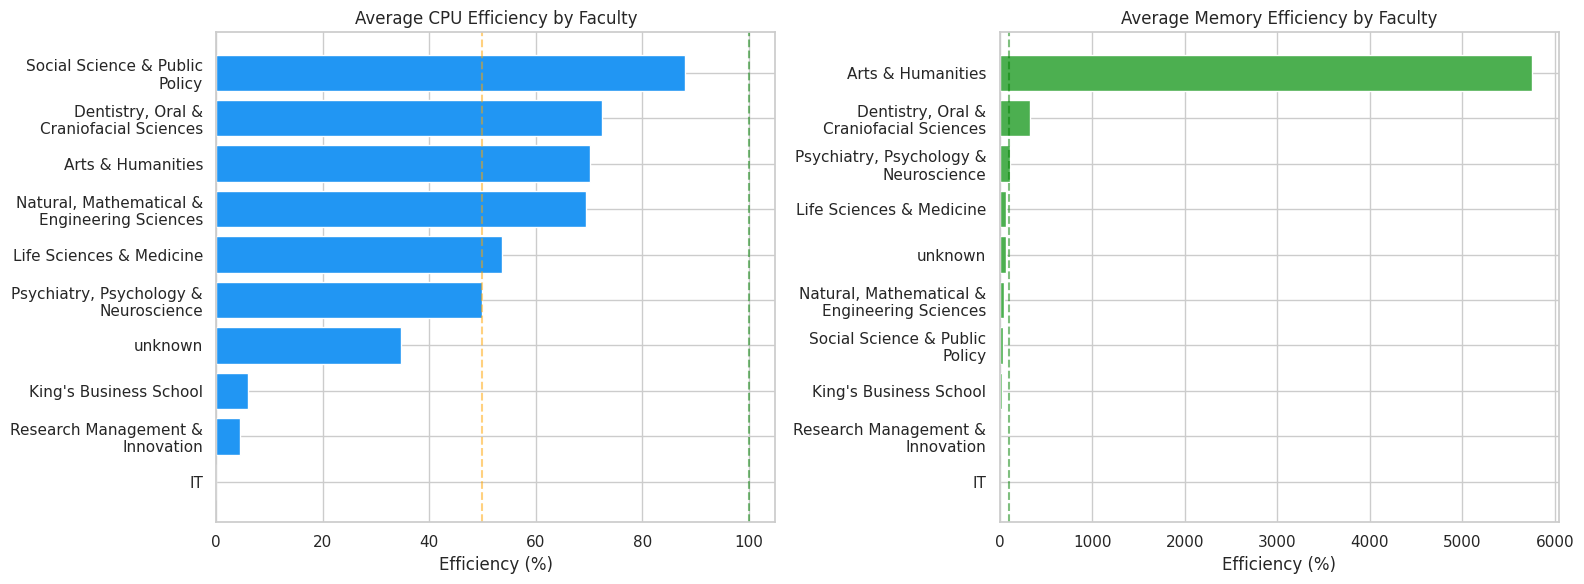

In [7]:
def plot_efficiency():
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    sorted_df = df_faculties.sort_values(CPU_EFF_COL, ascending=True)
    axes[0].barh(sorted_df['faculty_short'], sorted_df[CPU_EFF_COL], color='#2196f3')
    axes[0].set_xlabel('Efficiency (%)')
    axes[0].set_title('Average CPU Efficiency by Faculty')
    axes[0].axvline(x=100, color='green', linestyle='--', alpha=0.5)
    axes[0].axvline(x=50, color='orange', linestyle='--', alpha=0.5)
    
    sorted_df = df_faculties.sort_values(MEM_EFF_COL, ascending=True)
    axes[1].barh(sorted_df['faculty_short'], sorted_df[MEM_EFF_COL], color='#4caf50')
    axes[1].set_xlabel('Efficiency (%)')
    axes[1].set_title('Average Memory Efficiency by Faculty')
    axes[1].axvline(x=100, color='green', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

plot_efficiency()

## 3.2 Job Success/Failure

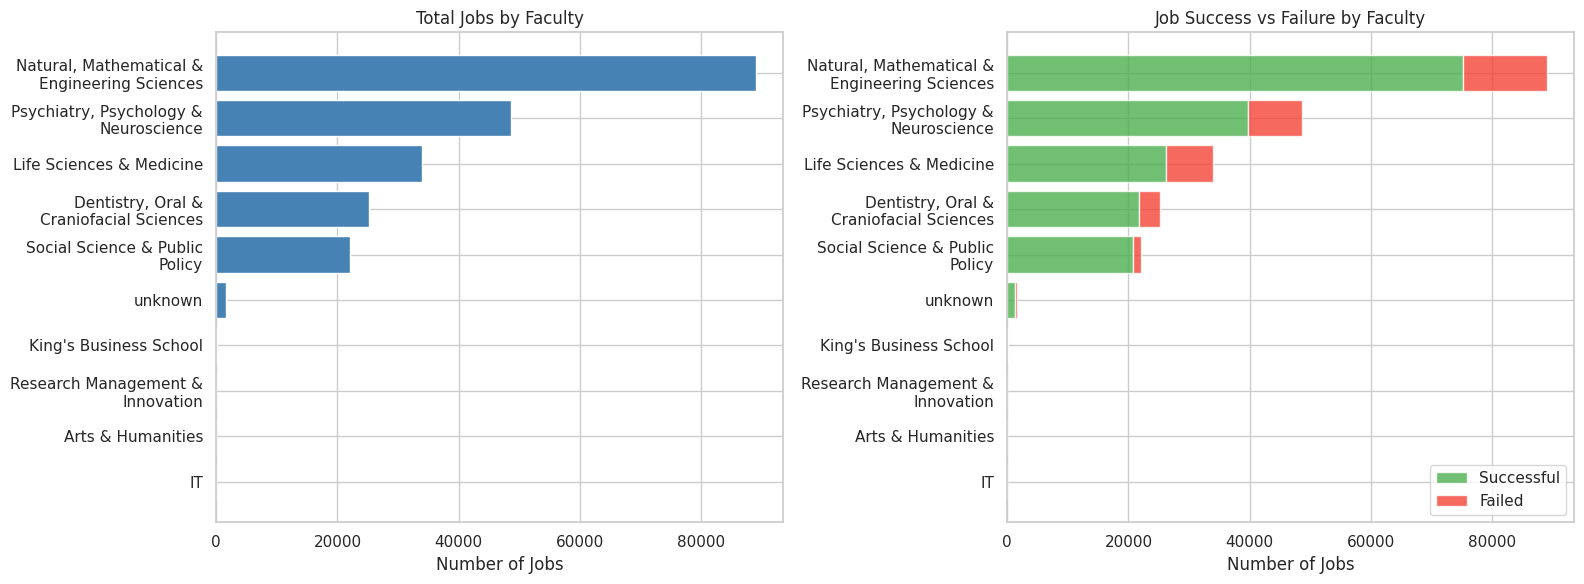

In [8]:
def plot_job_counts():
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sorted_df = df_faculties.sort_values('job_count', ascending=True)
    
    axes[0].barh(sorted_df['faculty_short'], sorted_df['job_count'], color='steelblue')
    axes[0].set_xlabel('Number of Jobs')
    axes[0].set_title('Total Jobs by Faculty')
    
    axes[1].barh(sorted_df['faculty_short'], sorted_df['job_count_success'], 
                 label='Successful', color='#4caf50', alpha=0.8)
    axes[1].barh(sorted_df['faculty_short'], sorted_df['job_count_failed'], 
                 left=sorted_df['job_count_success'], label='Failed', color='#f44336', alpha=0.8)
    axes[1].set_xlabel('Number of Jobs')
    axes[1].set_title('Job Success vs Failure by Faculty')
    axes[1].legend(loc='lower right')
    
    plt.tight_layout()
    plt.show()

plot_job_counts()

---
# 4. Job-Level Distributions

Understanding the **distribution** of efficiency across jobs helps identify common patterns and outliers. This section uses per-job data to show the full range of job efficiency.

## 4.1 Efficiency Distributions

Violin plots show the distribution of efficiency within each faculty. All violins are scaled to the same maximum width, so their shapes show the *relative* distribution within each faculty.

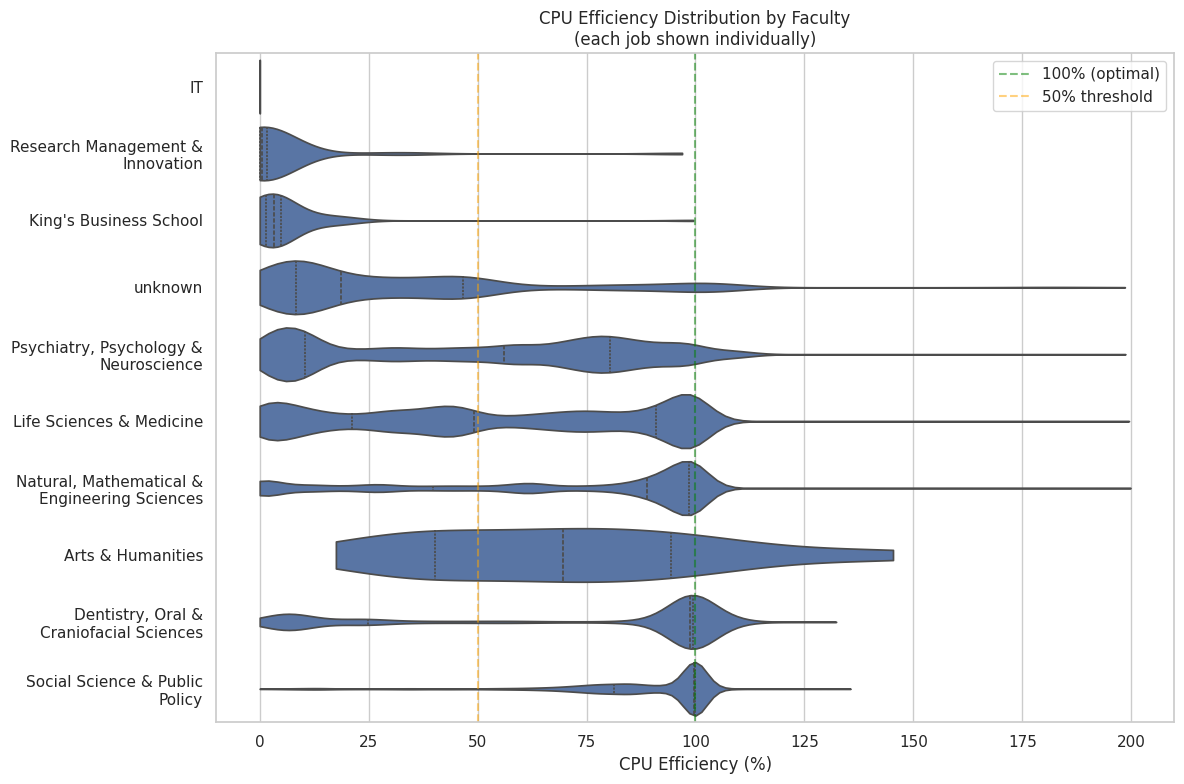

In [9]:
def plot_violin_cpu_efficiency():
    """Violin plot of CPU efficiency distribution by faculty."""
    if not HAS_JOB_DATA:
        print("Per-job data not available. Run hpc-job-stats first.")
        return
    
    if 'faculty' not in df_jobs.columns:
        print("Faculty column not in job data. Run hpc-job-stats with --include-faculty.")
        return
    
    plot_data = df_jobs[df_jobs['cpu_eff_pct'].notna() & (df_jobs['cpu_eff_pct'] <= 200)].copy()
    top_faculties = plot_data['faculty'].value_counts().head(10).index.tolist()
    plot_data = plot_data[plot_data['faculty'].isin(top_faculties)]
    
    ranking = (df_faculties[df_faculties['faculty'].isin(top_faculties)]
               .sort_values(CPU_EFF_COL))
    order = [FACULTY_SHORT.get(f, f) for f in ranking['faculty']]
    
    fig, ax = plt.subplots(figsize=(12, 8))
    sns.violinplot(data=plot_data, y='faculty_short', x='cpu_eff_pct', ax=ax,
                   cut=0, order=order, density_norm='width', inner='quartile')
    ax.axvline(x=100, color='green', linestyle='--', alpha=0.5, label='100% (optimal)')
    ax.axvline(x=50, color='orange', linestyle='--', alpha=0.5, label='50% threshold')
    ax.set_ylabel('')
    ax.set_xlabel('CPU Efficiency (%)')
    ax.set_title('CPU Efficiency Distribution by Faculty\n(each job shown individually)')
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_violin_cpu_efficiency()

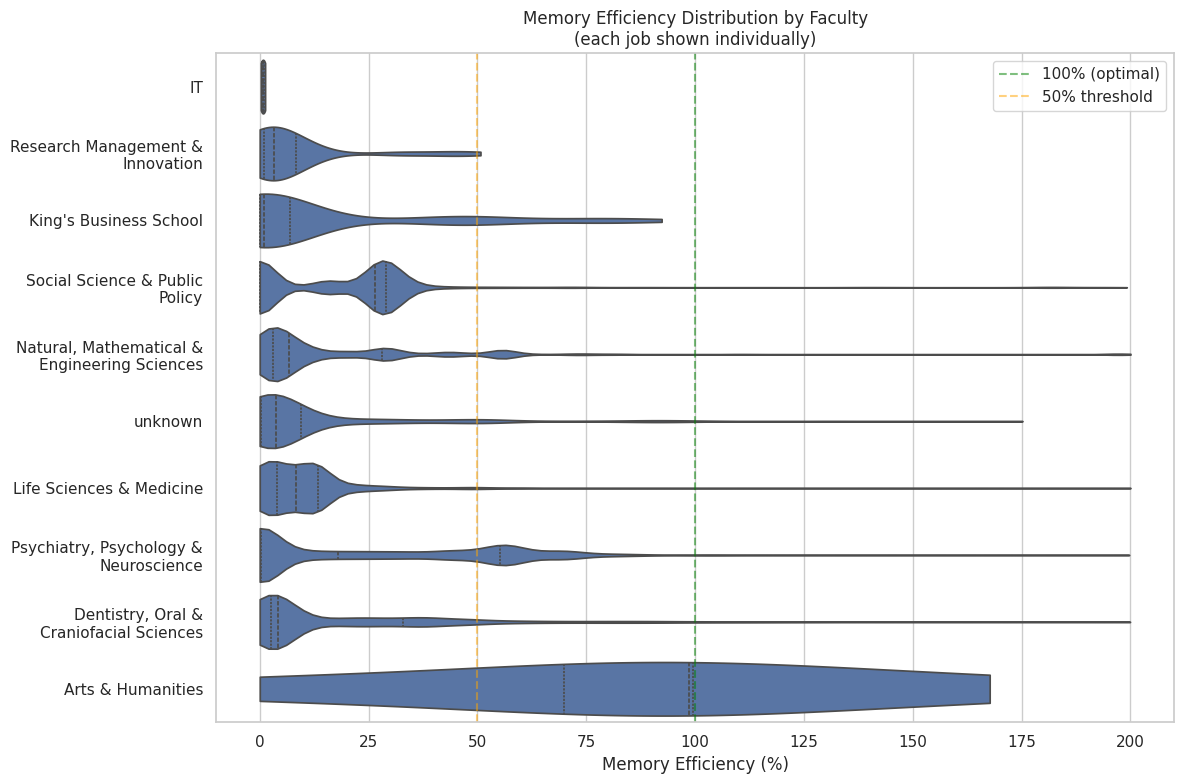

In [10]:
def plot_violin_memory_efficiency():
    """Violin plot of memory efficiency distribution by faculty."""
    if not HAS_JOB_DATA:
        print("Per-job data not available.")
        return
    
    if 'faculty' not in df_jobs.columns:
        print("Faculty column not in job data.")
        return
    
    plot_data = df_jobs[df_jobs['mem_eff_pct'].notna() & (df_jobs['mem_eff_pct'] <= 200)].copy()
    top_faculties = plot_data['faculty'].value_counts().head(10).index.tolist()
    plot_data = plot_data[plot_data['faculty'].isin(top_faculties)]
    
    ranking = (df_faculties[df_faculties['faculty'].isin(top_faculties)]
               .sort_values(MEM_EFF_COL))
    order = [FACULTY_SHORT.get(f, f) for f in ranking['faculty']]
    
    fig, ax = plt.subplots(figsize=(12, 8))
    sns.violinplot(data=plot_data, y='faculty_short', x='mem_eff_pct', ax=ax,
                   cut=0, order=order, density_norm='width', inner='quartile')
    ax.axvline(x=100, color='green', linestyle='--', alpha=0.5, label='100% (optimal)')
    ax.axvline(x=50, color='orange', linestyle='--', alpha=0.5, label='50% threshold')
    ax.set_ylabel('')
    ax.set_xlabel('Memory Efficiency (%)')
    ax.set_title('Memory Efficiency Distribution by Faculty\n(each job shown individually)')
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_violin_memory_efficiency()

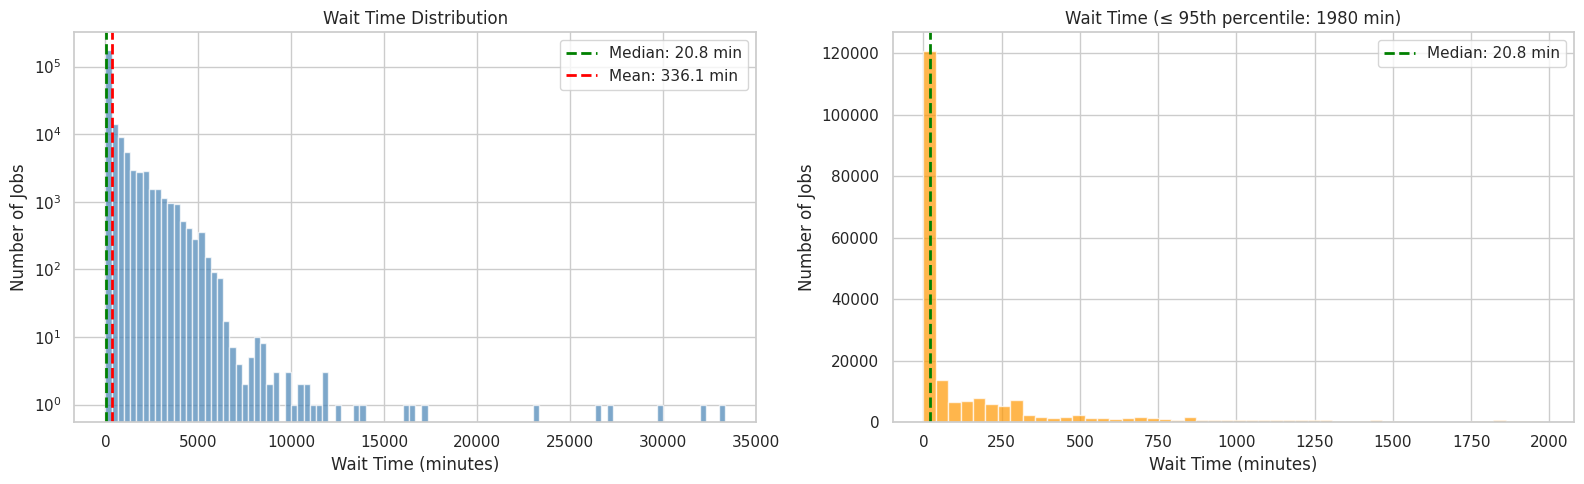


**Your typical wait time:** Most jobs (95%) wait less than **1980 minutes**.
The median wait is **20.8 minutes** — half of all jobs start faster than this.


In [11]:
def plot_wait_time_distribution():
    """Histogram of wait times."""
    if not HAS_JOB_DATA:
        print("Per-job data not available.")
        return
    
    wait_data = df_jobs['wait_sec'].dropna()
    wait_minutes = wait_data / 60
    
    median = wait_minutes.median()
    mean = wait_minutes.mean()
    p95 = wait_minutes.quantile(0.95)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    axes[0].hist(wait_minutes, bins=100, color='steelblue', alpha=0.7, edgecolor='white')
    axes[0].axvline(median, color='green', linestyle='--', linewidth=2, label=f'Median: {median:.1f} min')
    axes[0].axvline(mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean:.1f} min')
    axes[0].set_xlabel('Wait Time (minutes)')
    axes[0].set_ylabel('Number of Jobs')
    axes[0].set_title('Wait Time Distribution')
    axes[0].set_yscale('log')
    axes[0].legend()
    
    zoomed = wait_minutes[wait_minutes <= p95]
    axes[1].hist(zoomed, bins=50, color='#ff9800', alpha=0.7, edgecolor='white')
    axes[1].axvline(median, color='green', linestyle='--', linewidth=2, label=f'Median: {median:.1f} min')
    axes[1].set_xlabel('Wait Time (minutes)')
    axes[1].set_ylabel('Number of Jobs')
    axes[1].set_title(f'Wait Time (≤ 95th percentile: {p95:.0f} min)')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()
    
    display(Markdown(f"""
**Your typical wait time:** Most jobs ({len(zoomed)/len(wait_minutes)*100:.0f}%) wait less than **{p95:.0f} minutes**.
The median wait is **{median:.1f} minutes** — half of all jobs start faster than this.
"""))

plot_wait_time_distribution()

## 4.2 Efficiency > 100% Analysis

Jobs with efficiency above 100% indicate either:
- **CPU >100%**: Code uses more threads than CPUs requested (user under-requesting)
- **Memory >100%**: Job used more memory than requested (possible when memory limits weren't enforced)

In [12]:
def efficiency_over_100_summary():
    """Global and per-faculty summary of jobs with efficiency > 100%."""
    if not HAS_JOB_DATA:
        print("Per-job data not available.")
        return
    
    # Global summary
    total_jobs = len(df_jobs)
    
    cpu_valid = df_jobs['cpu_eff_pct'].notna()
    cpu_over_100 = (df_jobs['cpu_eff_pct'] > 100).sum()
    cpu_over_100_pct = cpu_over_100 / cpu_valid.sum() * 100
    
    mem_valid = df_jobs['mem_eff_pct'].notna()
    mem_over_100 = (df_jobs['mem_eff_pct'] > 100).sum()
    mem_over_100_pct = mem_over_100 / mem_valid.sum() * 100
    
    display(Markdown(f"""
### Global Summary

| Metric | Jobs > 100% | % of valid jobs |
|--------|-------------|-----------------|
| **CPU Efficiency** | {cpu_over_100:,} | {cpu_over_100_pct:.1f}% |
| **Memory Efficiency** | {mem_over_100:,} | {mem_over_100_pct:.1f}% |

*Valid jobs = jobs with non-null efficiency values*
"""))
    
    # Per-faculty breakdown
    if 'faculty' not in df_jobs.columns:
        print("Faculty column not available.")
        return
    
    faculty_stats = []
    for faculty in df_jobs['faculty'].dropna().unique():
        fac_jobs = df_jobs[df_jobs['faculty'] == faculty]
        total = len(fac_jobs)
        
        cpu_valid_n = fac_jobs['cpu_eff_pct'].notna().sum()
        cpu_over = (fac_jobs['cpu_eff_pct'] > 100).sum()
        cpu_pct = (cpu_over / cpu_valid_n * 100) if cpu_valid_n > 0 else 0
        
        mem_valid_n = fac_jobs['mem_eff_pct'].notna().sum()
        mem_over = (fac_jobs['mem_eff_pct'] > 100).sum()
        mem_pct = (mem_over / mem_valid_n * 100) if mem_valid_n > 0 else 0
        
        faculty_stats.append({
            'Faculty': faculty,
            'Total Jobs': total,
            'CPU >100%': f"{cpu_pct:.1f}%",
            'Mem >100%': f"{mem_pct:.1f}%"
        })
    
    faculty_df = pd.DataFrame(faculty_stats)
    faculty_df = faculty_df.sort_values('Total Jobs', ascending=False)
    
    display(Markdown("### Per-Faculty Breakdown"))
    display(faculty_df.style.hide(axis='index'))

efficiency_over_100_summary()


### Global Summary

| Metric | Jobs > 100% | % of valid jobs |
|--------|-------------|-----------------|
| **CPU Efficiency** | 7,094 | 3.2% |
| **Memory Efficiency** | 20,565 | 9.3% |

*Valid jobs = jobs with non-null efficiency values*


### Per-Faculty Breakdown

Faculty,Total Jobs,CPU >100%,Mem >100%
"Faculty of Natural, Mathematical & Engineering Sciences",89044,2.1%,5.9%
"Institute of Psychiatry, Psychology & Neuroscience",48634,3.9%,11.0%
Faculty of Life Sciences & Medicine,34005,0.7%,7.8%
"Faculty of Dentistry, Oral & Craniofacial Sciences",25190,9.8%,24.5%
Faculty of Social Science & Public Policy,22147,2.3%,4.6%
unknown,1575,6.8%,10.7%
King's Business School,72,0.0%,1.4%
Research Management & Innovation,44,0.0%,0.0%
Faculty of Arts & Humanities,28,21.4%,85.7%
IT,2,0.0%,0.0%


In [ ]:
def plot_efficiency_severity_global():
    """Bar plot showing distribution of efficiency by severity bins (global)."""
    if 'df_jobs' not in globals() or df_jobs is None:
        print("Per-job data not available. Run cells above first.")
        return
    
    # Define bins
    bins = [0, 100, 150, 200, 500, float('inf')]
    labels = ['<100%', '100-150%', '150-200%', '200-500%', '>500%']
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # CPU efficiency
    cpu_data = df_jobs['cpu_eff_pct'].dropna()
    cpu_binned = pd.cut(cpu_data, bins=bins, labels=labels, right=False)
    cpu_counts = cpu_binned.value_counts().reindex(labels, fill_value=0)
    cpu_total = cpu_counts.sum()
    cpu_pcts = (cpu_counts / cpu_total * 100).values
    
    colors = ['#4caf50', '#ffeb3b', '#ff9800', '#f44336', '#9c27b0']
    axes[0].bar(labels, cpu_counts.values, color=colors, edgecolor='white')
    axes[0].set_xlabel('Efficiency Range')
    axes[0].set_ylabel('Number of Jobs')
    axes[0].set_title('CPU Efficiency Distribution (Global)')
    for i, (v, pct) in enumerate(zip(cpu_counts.values, cpu_pcts)):
        if v > 0:
            axes[0].text(i, v + max(cpu_counts.values)*0.02, f'{pct:.1f}%', ha='center', fontsize=9)
    
    # Memory efficiency
    mem_data = df_jobs['mem_eff_pct'].dropna()
    mem_binned = pd.cut(mem_data, bins=bins, labels=labels, right=False)
    mem_counts = mem_binned.value_counts().reindex(labels, fill_value=0)
    mem_total = mem_counts.sum()
    mem_pcts = (mem_counts / mem_total * 100).values
    
    axes[1].bar(labels, mem_counts.values, color=colors, edgecolor='white')
    axes[1].set_xlabel('Efficiency Range')
    axes[1].set_ylabel('Number of Jobs')
    axes[1].set_title('Memory Efficiency Distribution (Global)')
    for i, (v, pct) in enumerate(zip(mem_counts.values, mem_pcts)):
        if v > 0:
            axes[1].text(i, v + max(mem_counts.values)*0.02, f'{pct:.1f}%', ha='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()

plot_efficiency_severity_global()

In [ ]:
from ipywidgets import interact, Dropdown

def plot_efficiency_severity_faculty(faculty):
    """Bar plot showing distribution of efficiency by severity bins for selected faculty."""
    fac_jobs = df_jobs[df_jobs['faculty'] == faculty]
    
    # Define bins
    bins = [0, 100, 150, 200, 500, float('inf')]
    labels = ['<100%', '100-150%', '150-200%', '200-500%', '>500%']
    colors = ['#4caf50', '#ffeb3b', '#ff9800', '#f44336', '#9c27b0']
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # CPU efficiency
    cpu_data = fac_jobs['cpu_eff_pct'].dropna()
    if len(cpu_data) > 0:
        cpu_binned = pd.cut(cpu_data, bins=bins, labels=labels, right=False)
        cpu_counts = cpu_binned.value_counts().reindex(labels, fill_value=0)
        cpu_total = cpu_counts.sum()
        cpu_pcts = (cpu_counts / cpu_total * 100).values if cpu_total > 0 else [0]*len(labels)
        axes[0].bar(labels, cpu_counts.values, color=colors, edgecolor='white')
        for i, (v, pct) in enumerate(zip(cpu_counts.values, cpu_pcts)):
            if v > 0:
                axes[0].text(i, v + max(cpu_counts.values)*0.03, f'{pct:.1f}%', ha='center', fontsize=9)
    axes[0].set_xlabel('Efficiency Range')
    axes[0].set_ylabel('Number of Jobs')
    axes[0].set_title(f'CPU Efficiency Distribution')
    
    # Memory efficiency
    mem_data = fac_jobs['mem_eff_pct'].dropna()
    if len(mem_data) > 0:
        mem_binned = pd.cut(mem_data, bins=bins, labels=labels, right=False)
        mem_counts = mem_binned.value_counts().reindex(labels, fill_value=0)
        mem_total = mem_counts.sum()
        mem_pcts = (mem_counts / mem_total * 100).values if mem_total > 0 else [0]*len(labels)
        axes[1].bar(labels, mem_counts.values, color=colors, edgecolor='white')
        for i, (v, pct) in enumerate(zip(mem_counts.values, mem_pcts)):
            if v > 0:
                axes[1].text(i, v + max(mem_counts.values)*0.03, f'{pct:.1f}%', ha='center', fontsize=9)
    axes[1].set_xlabel('Efficiency Range')
    axes[1].set_ylabel('Number of Jobs')
    axes[1].set_title(f'Memory Efficiency Distribution')
    
    plt.suptitle(f'{faculty} ({len(fac_jobs):,} jobs)', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

if 'df_jobs' in globals() and df_jobs is not None and 'faculty' in df_jobs.columns:
    faculties_sorted = df_jobs['faculty'].value_counts().index.tolist()
    interact(plot_efficiency_severity_faculty, 
             faculty=Dropdown(options=faculties_sorted, description='Faculty:',
                             style={'description_width': 'initial'}))
else:
    print("Per-job data with faculty column not available. Run cells above first.")

---
# 5. Correlation Analysis

Exploring relationships between CPU and memory efficiency across faculties.

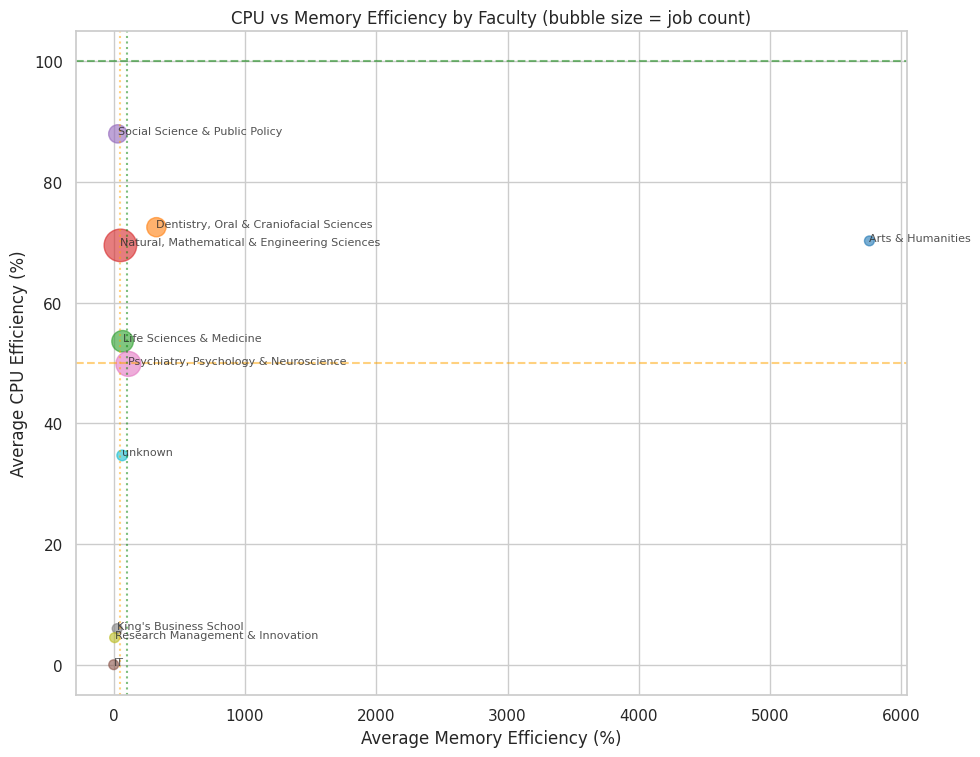

In [15]:
def cpu_memory_scatter():
    """Scatter plot: CPU vs Memory efficiency by faculty."""
    fig, ax = plt.subplots(figsize=(10, 8))
    
    plot_df = df_faculties.dropna(subset=[CPU_EFF_COL, MEM_EFF_COL])
    
    ax.scatter(plot_df[MEM_EFF_COL], plot_df[CPU_EFF_COL],
               s=plot_df['job_count']/plot_df['job_count'].max()*500+50,
               alpha=0.6, c=range(len(plot_df)), cmap='tab10')
    
    for idx, row in plot_df.iterrows():
        ax.annotate(row['faculty_short'].replace('\n', ' '),
                    (row[MEM_EFF_COL], row[CPU_EFF_COL]),
                   fontsize=8, alpha=0.8)
    
    ax.axhline(y=50, color='orange', linestyle='--', alpha=0.5)
    ax.axhline(y=100, color='green', linestyle='--', alpha=0.5)
    ax.axvline(x=50, color='orange', linestyle=':', alpha=0.5)
    ax.axvline(x=100, color='green', linestyle=':', alpha=0.5)
    
    ax.set_xlabel('Average Memory Efficiency (%)')
    ax.set_ylabel('Average CPU Efficiency (%)')
    ax.set_title('CPU vs Memory Efficiency by Faculty (bubble size = job count)')
    plt.tight_layout()
    plt.show()

cpu_memory_scatter()

---
# 6. Why Efficiency Matters

## The Problem: Resource Waste

When you request resources (CPUs, memory) for your job, those resources are **reserved exclusively for you**, even if you don't use them. This means:

- Other users can't run their jobs while your resources sit idle
- Queue wait times increase for everyone
- The cluster appears "full" when it's actually underutilised

## What "Good" Efficiency Looks Like

| Range | Rating | Meaning |
|-------|--------|---------||
| 70–100% | Excellent | You're using what you requested |
| 30–70% | Acceptable | Room for improvement |
| <30% | Poor | Significant waste — please optimise |

## How to Improve Your Efficiency

1. **Profile your jobs first** — Run a small test job and check actual resource usage with `seff <jobid>`
2. **Request what you need (plus 10–20% buffer)** — If your test used 8 GB, request 10 GB, not 64 GB
3. **Use job arrays for many small jobs** — Instead of requesting 100 CPUs for one job, submit 100 single-CPU jobs
4. **Check your code's parallelisation** — If you request 16 CPUs but your code only uses 1, you're wasting 15 CPUs

---
# 7. Technical Appendix

## Data Sources

- **Job data:** Slurm accounting database (MySQL), accessed directly via `mysql.connector` (not via `sacct`, for reliability).
  - `create_job_table`: job metadata — timestamps, resource requests (`cpus_req`, `tres_req`), state, time limit
  - `create_step_table`: per-step CPU time (`user_sec`, `sys_sec`) and peak memory usage (`tres_usage_in_max`)
  - `create_assoc_table`: maps job associations to usernames
- **Faculty mapping:** Active Directory via LDAP. Each username is looked up to retrieve its faculty attribute (`st`).

## Efficiency Metrics

### Average vs Weighted

This notebook uses **average efficiency** — the mean of per-job efficiency values. Each job counts equally, regardless of size.

| Version | Formula | Question it answers |
|---------|---------|---------------------|
| **Average** | Mean(per-job efficiency) | "What's the typical job's efficiency?" Each job counts equally. |
| **Weighted** | Sum(used) / Sum(allocated) × 100 | "How efficiently are allocated resources being used overall?" Larger jobs contribute more. |

For infrastructure planning (where large jobs matter more), see `visualisation_infrastructure.ipynb`.

### CPU Efficiency

`CPU Efficiency = TotalCPU / (Elapsed × CPUs Requested) × 100`

- **TotalCPU** = user-mode CPU seconds + system-mode CPU seconds + microsecond fractions.
- **CPUs Requested** = `cpus_req` from the job table.

**Why it can exceed 100%:** If your code uses more threads than CPUs requested, Slurm still only knows about the requested CPUs. For example, requesting 1 CPU but running 4 OpenMP threads gives ~400% efficiency. This indicates under-requesting — users should request CPUs matching their thread count (`--cpus-per-task=4` for 4-threaded code).

**Why allocated CPUs sometimes exceed requested CPUs:** The cluster uses core-level allocation (`CR_Core` in Slurm). On hyperthreaded nodes (2 threads per core), requesting 1 CPU allocates 1 whole core = 2 logical CPUs. This is cluster configuration, not user error.

### Memory Efficiency

`Memory Efficiency = MaxRSS / ReqMem × 100`

- **MaxRSS**: Peak memory usage across all steps.
- **ReqMem**: Requested memory (always stored as total memory regardless of `--mem` vs `--mem-per-cpu`).

**Why it can exceed 100%:** The data in this analysis is from a period when memory limits were **not enforced** (`ConstrainRAMSpace` was disabled). Jobs could exceed requested memory without being killed. Memory enforcement has since been enabled — new jobs exceeding their memory request will be terminated.

### Time Efficiency

`Time Efficiency = Elapsed / (Timelimit × 60) × 100`

Measures what fraction of the requested wall-clock time was actually used.

## Resource Enforcement (cgroups)

Slurm can enforce resource limits using Linux cgroups:

| Resource | Setting | Status | Effect |
|----------|---------|--------|--------|
| Memory | `ConstrainRAMSpace` | Now enabled | Jobs killed if exceeding request |
| CPU | `ConstrainCores` | Not enabled | Jobs can use more cores than requested |

Because CPU enforcement is not enabled, jobs can spawn more threads than requested and use other cores on the node. This explains CPU efficiency > 100% in the data.

## Job States Included

Only jobs in specific terminal states are included:

| State | Included | Why |
|-------|----------|-----|
| COMPLETED | **Yes** | Clean efficiency data |
| TIMEOUT | **Yes** | Job ran its full requested time |
| OUT_OF_MEMORY | **Yes** | Shows memory under-requesting |
| CANCELLED, FAILED, NODE_FAIL, PREEMPTED | No | Incomplete, potentially misleading |

In [16]:
display(Markdown("### Raw Faculty Data"))
display(df_faculties)

### Raw Faculty Data

,faculty,job_count,job_count_success,job_count_failed,count_completed,count_cancelled,count_failed,count_timeout,count_node_fail,count_preempted,...,avg_cpu_eff_pct,avg_mem_eff_pct,avg_time_eff_pct,success_weighted_cpu_eff_pct,success_avg_cpu_eff_pct,success_weighted_mem_eff_pct,success_avg_mem_eff_pct,success_weighted_time_eff_pct,success_avg_time_eff_pct,faculty_short
0,Faculty of Arts & Humanities,28,16,12,16,2,10,0,0,0,...,70.230000,5756.120000,2.750000,85.740000,79.440000,2675.240000,7387.330000,2.640000,2.420000,Arts & Humanities
1,"Faculty of Dentistry, Oral & Craniofacial Scie...",25190,21742,3448,21742,893,1647,102,0,806,...,72.499512,325.812124,9.603505,25.701555,71.956090,396.273659,325.515714,9.253632,9.079118,"Dentistry, Oral &\nCraniofacial Sciences"
2,Faculty of Life Sciences & Medicine,34005,26235,7770,26235,560,6948,254,2,6,...,53.595363,68.333051,5.581935,43.192117,58.969672,48.205686,67.461347,0.000000,5.088197,Life Sciences & Medicine
3,"Faculty of Natural, Mathematical & Engineering...",89044,75235,13809,75235,2773,8972,1788,13,263,...,69.490000,51.700000,30.110000,69.680000,74.860000,20.750000,47.360000,0.000000,32.010000,"Natural, Mathematical &\nEngineering Sciences"
4,Faculty of Social Science & Public Policy,22147,20752,1395,20752,13,1317,64,0,1,...,87.961467,31.998955,13.995538,99.331542,89.051752,33.235742,33.470928,14.606831,14.608875,Social Science & Public\nPolicy
5,IT,2,0,2,0,0,0,2,0,0,...,0.010000,0.750000,100.000000,NaN,NaN,NaN,NaN,NaN,NaN,IT
6,"Institute of Psychiatry, Psychology & Neurosci...",48634,39798,8836,39798,1221,7373,233,0,9,...,49.844720,112.654413,7.138245,64.507733,51.244108,32.988572,129.822558,0.000000,6.094618,"Psychiatry, Psychology &\nNeuroscience"
7,King's Business School,72,64,8,64,1,6,1,0,0,...,5.990000,27.210000,8.010000,13.920000,6.300000,23.280000,24.460000,3.030000,2.520000,King's Business School
8,Research Management & Innovation,44,13,31,13,16,4,11,0,0,...,4.490000,7.850000,35.950000,0.010000,13.160000,6.730000,3.640000,20.320000,11.480000,Research Management &\nInnovation
9,unknown,1575,1348,227,1348,52,156,19,0,0,...,34.690000,65.540000,3.880000,67.620000,35.030000,24.160000,72.270000,0.000000,1.770000,unknown
